In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt

import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [94]:
index_min = 50
index_max = 250

E = data['E'][index_min:index_max]
Q = data['q'][index_min:index_max]
T = data['t'][index_min:index_max] / 2e-7


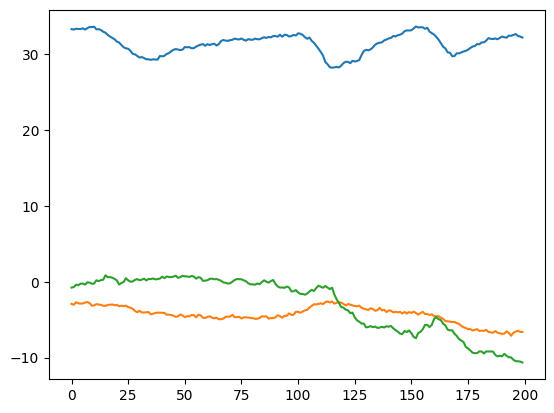

In [95]:
plt.plot(T)

In [96]:
N = data['n']

In [97]:
N.shape

(150, 174, 200)

In [98]:
E.shape

(200, 174, 200)

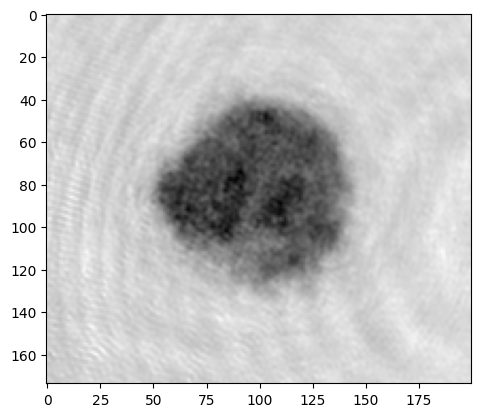

In [99]:
plt.imshow(E[0].real, cmap='gray')


In [100]:
N = torch.tensor(N, dtype=torch.float32, device=DEV)
E = torch.tensor(E, dtype=torch.complex64, device=DEV)
Q = torch.tensor(Q, dtype=torch.float32, device=DEV)
T = torch.tensor(T, dtype=torch.float32, device=DEV)


In [101]:
N = torch.moveaxis(N, 0, 2)  # Move the last dimension to the end

In [102]:
q_new = Q.clone()

q_new[...,1] = Q[...,2]
q_new[...,2] = Q[...,3]
q_new[...,3] = Q[...,1]

In [103]:
t_new = T.clone()

t_new[..., 0] = T[...,0] #0
t_new[..., 1] = T[..., 2]
t_new[..., 2] = T[..., 1]

In [104]:
t_new[0]

tensor([33.3344, -0.7726, -2.9241], device='cuda:0')

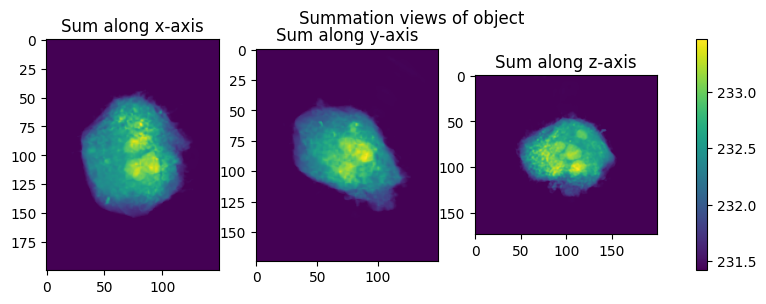

In [105]:
tomodpdt.plotting.plot_sum_object(N.cpu().numpy())

In [106]:
N = N[12:-12, 25:-25]

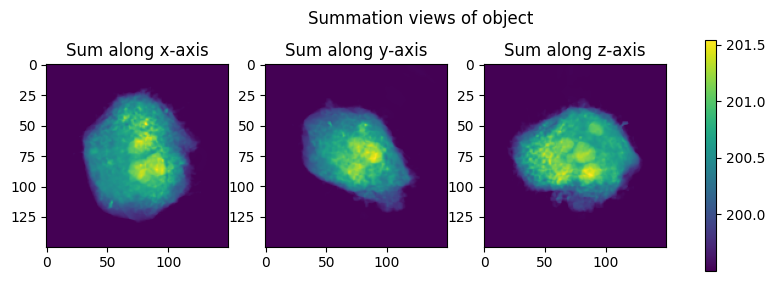

In [107]:
tomodpdt.plotting.plot_sum_object(N.cpu().numpy())

In [108]:
import tomodpdt.forward_module as FM

In [109]:
forward_model = FM.ForwardModelSimple(N=150)

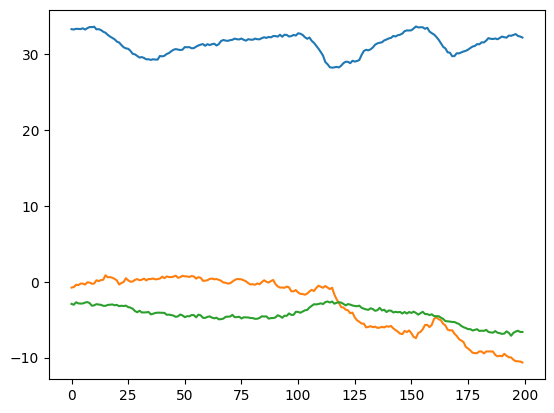

In [110]:
plt.plot(t_new.cpu().numpy())

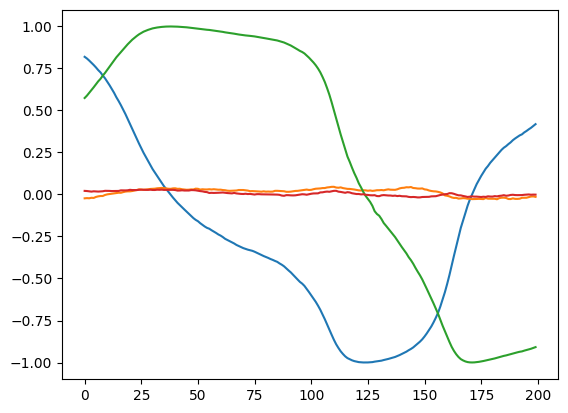

In [111]:
plt.plot(q_new.cpu().numpy())

In [112]:
k=50

In [113]:
q_new[k]

tensor([-0.1593,  0.0334,  0.9864,  0.0220], device='cuda:0')

In [114]:
t_new[k]

tensor([30.9701,  0.7133, -4.6779], device='cuda:0')

In [115]:
volume_new = forward_model.apply_rotation_translation(volume=N, q=q_new[k], translations=t_new[k])

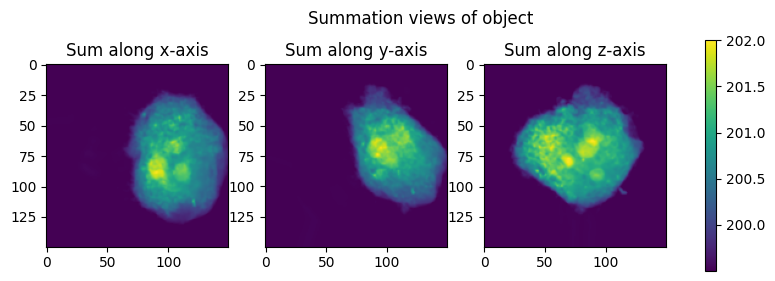

In [116]:
tomodpdt.plotting.plot_sum_object(volume_new.cpu().numpy())

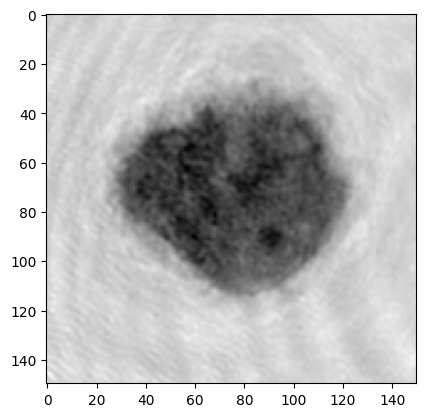

In [117]:
plt.imshow(E[k][12:-12, 25:-25].cpu().real, cmap='gray')

In [118]:
volume = np.load('../test_data/vol_potato1.npy') - 1.33

In [119]:
volume = torch.tensor(volume, dtype=torch.float32, device=DEV)

In [120]:
forward_model = FM.ForwardModelSimple(N=64)

In [121]:
translation = torch.tensor([10, 10, 10], dtype=torch.float32, device=DEV)

In [122]:
k = 20

In [123]:
volume_new = forward_model.apply_rotation_translation(
    volume=volume, 
    q=q_new[k], 
    translations=translation
    )

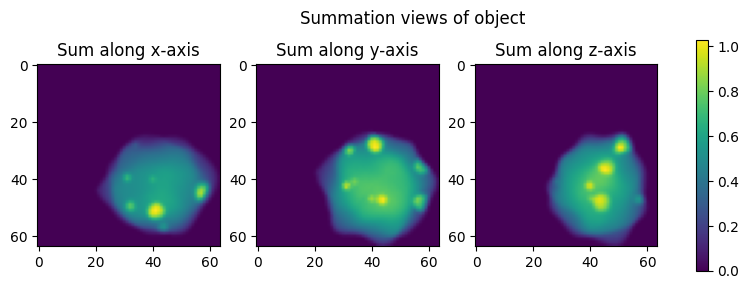

In [124]:
tomodpdt.plotting.plot_sum_object(volume_new.cpu().numpy())

In [125]:
#tomodpdt.plotting.visualize_3d_volume(volume_new.cpu().numpy())